In [1]:
# import dependencies
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
# open data
df_unfiltered = pd.read_csv('../data/cleaned/fema_hma_projects_clean.csv')
gdf = gpd.read_file('../data/cleaned/census.geojson')

# FEMA Hazard Mitigation Assistance Funding

In [3]:
# # filter to only include approved projects, and projects flagged for flood mitigation
keep_statuses = ["Approved", "Awarded", "Closed", "Completed", "Obligated"]
df = df_unfiltered[df_unfiltered["status"].isin(keep_statuses)].copy()
df = df[df["flood_mitigation_flag"] == 1]
print(df["status"].value_counts())

status
Closed       338
Approved      94
Obligated     13
Completed      1
Name: count, dtype: int64


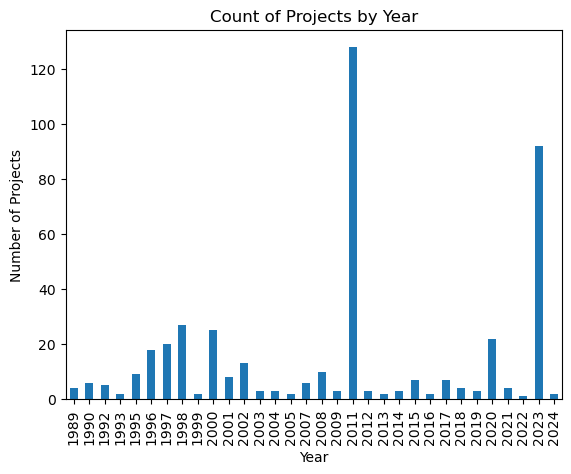

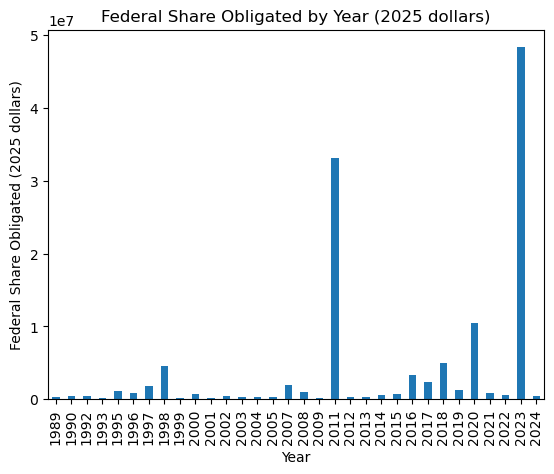

In [4]:
# plot count of projects by year
df['programFy'].value_counts().sort_index().plot(kind='bar')
plt.xlabel('Year')
plt.ylabel('Number of Projects')
plt.title('Count of Projects by Year')
plt.show()

# plot amount obligated by year
df.groupby('programFy')['federalShareObligated_adj'].sum().plot(kind='bar')
plt.xlabel('Year')
plt.ylabel('Federal Share Obligated (2025 dollars)')
plt.title('Federal Share Obligated by Year (2025 dollars)')
plt.show()

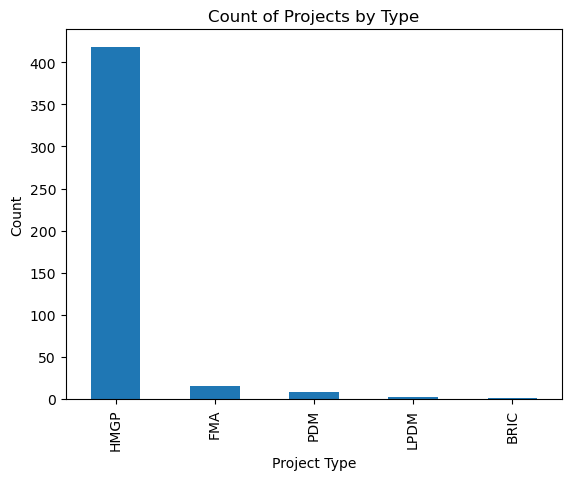

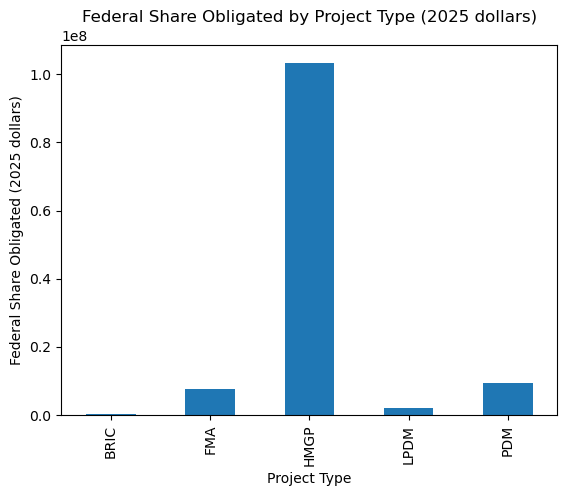

In [5]:
# print(df_unfiltered['programArea'].value_counts())
# print(df['programArea'].value_counts())

# plot count of projects by type
# Hazard Mitigation Assistance (HMA) program areas include:
# - Flood Mitigation Assistance (FMA)
# - Pre-Disaster Mitigation (PDM)
# - Hazard Mitigation Grant Program (HMGP)
# - Building Resilient Infrastructure and Communities (BRIC)
# - Legislative Pre-Disaster Mitigation (LPDM)
df['programArea'].value_counts().plot(kind='bar')
plt.xlabel('Project Type')
plt.ylabel('Count')
plt.title('Count of Projects by Type')
plt.show()

# plot federal_share_obligated_adj grouped by programArea
df.groupby('programArea')['federalShareObligated_adj'].sum().plot(kind='bar')
plt.xlabel('Project Type')
plt.ylabel('Federal Share Obligated (2025 dollars)')
plt.title('Federal Share Obligated by Project Type (2025 dollars)')
plt.show()

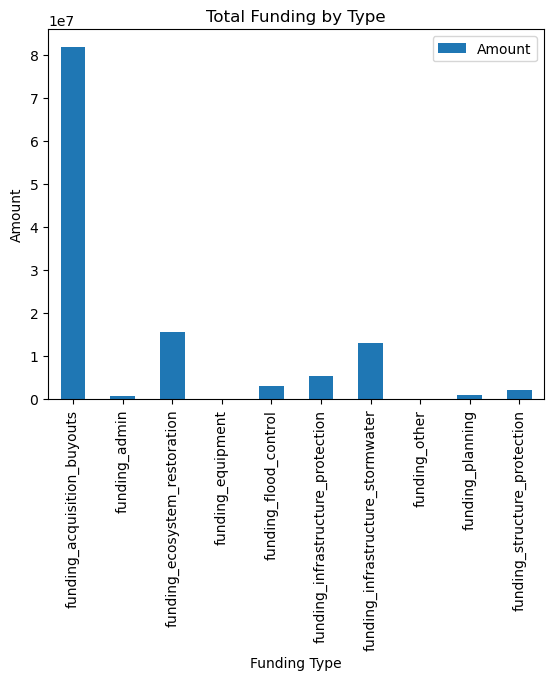

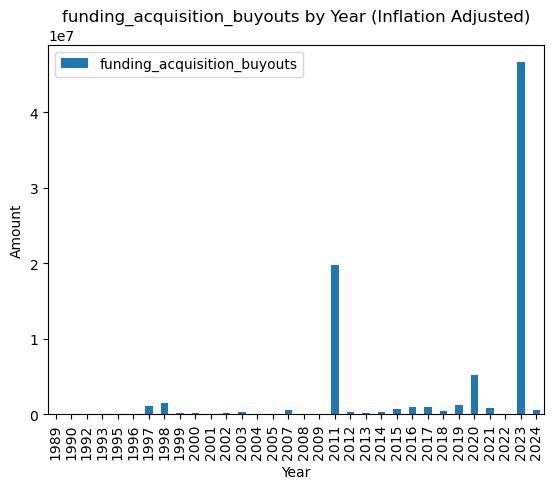

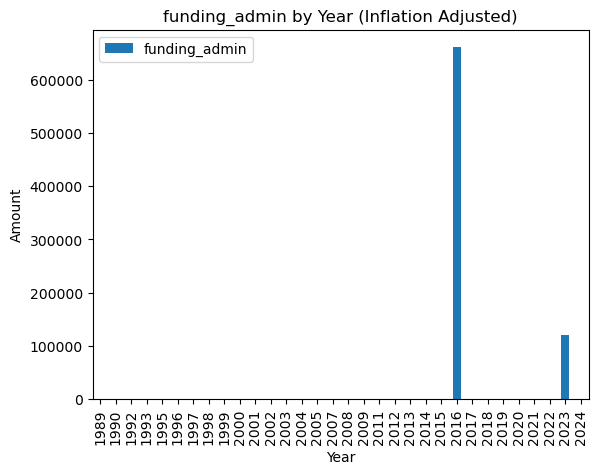

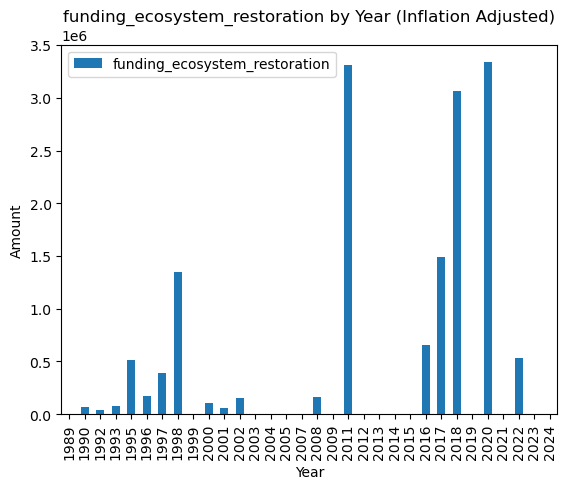

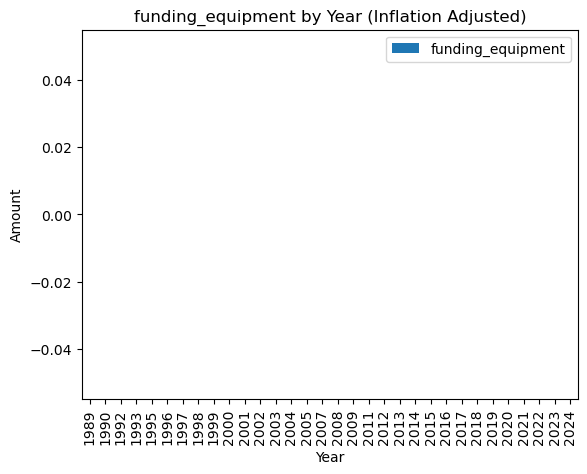

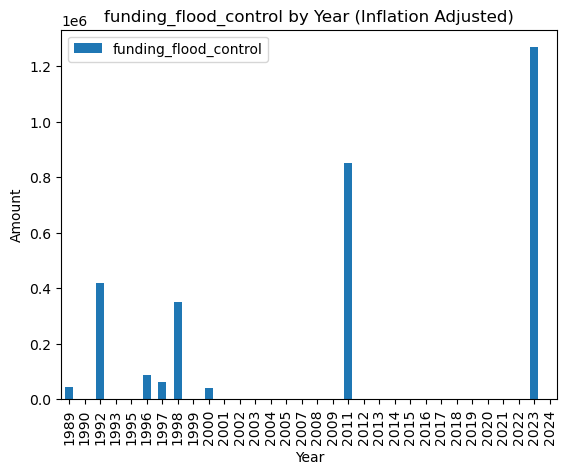

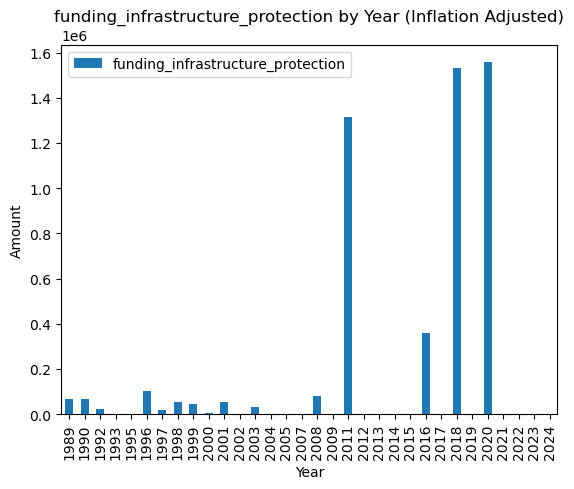

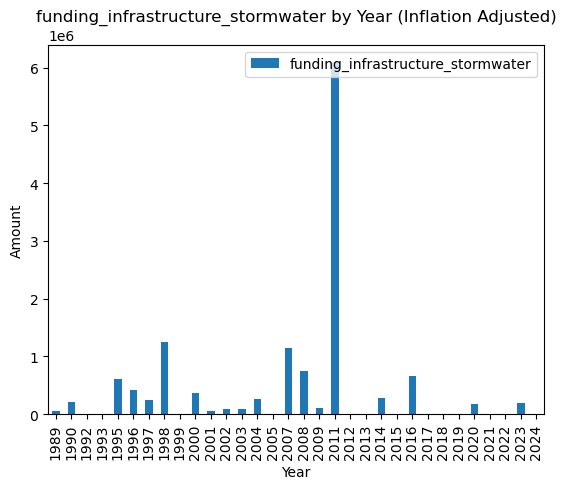

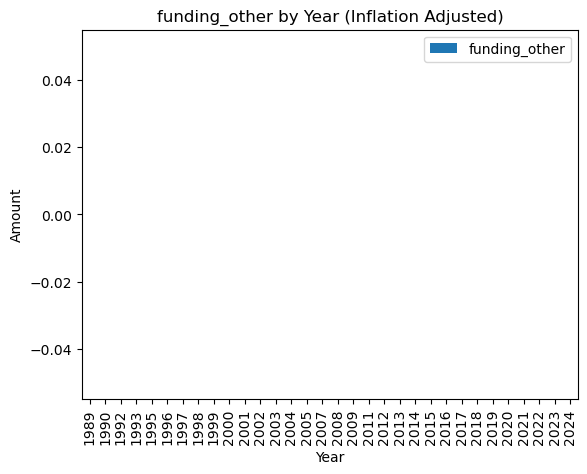

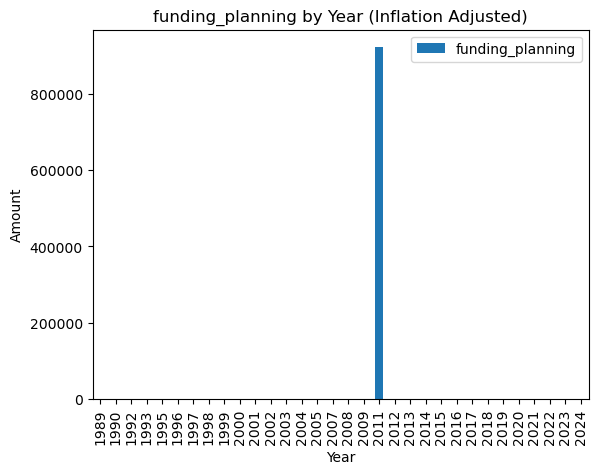

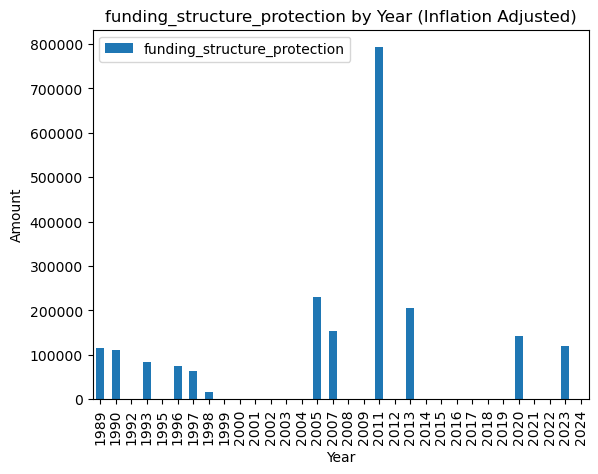

In [6]:
# plot all "funding_*" columns, grouped
funding_cols = [col for col in df.columns if col.startswith('funding_')]
funding_df = df[funding_cols].sum().reset_index()
funding_df.columns = ['Funding Type', 'Amount']
funding_df.plot(kind='bar', x='Funding Type', y='Amount')
plt.xlabel('Funding Type')
plt.ylabel('Amount')
plt.title('Total Funding by Type')
plt.show()

# plot all "funding_" columns by year, one plot per column
funding_year_df = df.groupby('programFy')[funding_cols].sum().reset_index()
for col in funding_cols:
    funding_year_df.plot(kind='bar', x='programFy', y=col)
    plt.xlabel('Year')
    plt.ylabel('Amount')
    plt.title(f'{col} by Year (Inflation Adjusted)')
    plt.show()

# NFIP Claims

In [7]:
# read in the data
df_nfip_claims = pd.read_csv('../data/raw/NFIP/vt_nfip_claims.csv')
# df_nfip_claims.columns

In [8]:
# create a dict of CPI adjustment factors for each year, using the most recent full year as the reference year

# open CPI csv and calculate annual average CPI values for each year
cpi = pd.read_csv("../data/resources/CPIAUCSL.csv")
cpi["DATE"] = pd.to_datetime(cpi["observation_date"])
cpi["year"] = cpi["DATE"].dt.year
cpi_annual = cpi.groupby("year")["CPIAUCSL"].mean().reset_index()
# display(cpi_annual.tail())

# get most recent full year
reference_year = cpi_annual["year"].max()
if pd.Timestamp.now().year == reference_year:
    reference_year -= 1
cpi_ref = cpi_annual.loc[cpi_annual["year"] == reference_year, "CPIAUCSL"].values[0]
print(f"Reference year: {reference_year}, CPI: {cpi_ref:.4f}")

# create a CPI lookup dictionary
cpi_lookup = dict(zip(cpi_annual["year"], cpi_annual["CPIAUCSL"]))
# calculate adjustment factors for each year in the dataset
# adjustment factor = CPI in reference year / CPI in project year
cpi_factors = {year: cpi_ref / cpi_value for year, cpi_value in cpi_lookup.items()}
# print("CPI adjustment factors:")
# for year, factor in cpi_factors.items():
#     print(f"{year}: {factor:.4f}")

Reference year: 2025, CPI: 321.9619


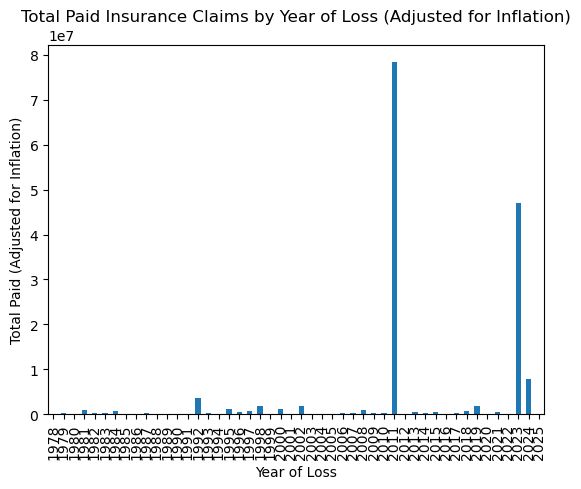

In [9]:
# sum amount paid in insurance claims
df_nfip_claims["total_paid"] = (
    df_nfip_claims["amountPaidOnBuildingClaim"].fillna(0)
    + df_nfip_claims["amountPaidOnContentsClaim"].fillna(0)
    + df_nfip_claims["amountPaidOnIncreasedCostOfComplianceClaim"].fillna(0)
)

# adjust total_paid for inflation to reference year dollars (most recent full year) using the CPI adjustment factors created above
df_nfip_claims["total_paid_adj"] = df_nfip_claims.apply(
    # inflation-adjusted dollars = nominal dollars * (CPI in reference year / CPI in project year)
    lambda row: row["total_paid"] * cpi_factors.get(row["yearOfLoss"], 1.0), axis=1
)

# plot total_paid_adj by yearOfLoss
df_nfip_claims.groupby("yearOfLoss")["total_paid_adj"].sum().plot(kind="bar")
plt.xlabel("Year of Loss")
plt.ylabel("Total Paid (Adjusted for Inflation)")
plt.title("Total Paid Insurance Claims by Year of Loss (Adjusted for Inflation)")
plt.show()

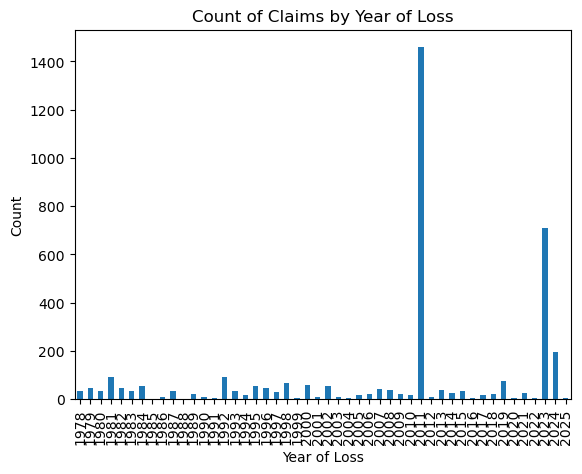

In [10]:
# plot count of yearOfLoss
df_nfip_claims['yearOfLoss'].value_counts().sort_index().plot(kind='bar')
plt.xlabel('Year of Loss')
plt.ylabel('Count')
plt.title('Count of Claims by Year of Loss')
plt.show()

# NFIP Policies

In [11]:
# load policies data (clean and merge after claims data)
df_nfip_policies = pd.read_csv("../data/raw/NFIP/vt_nfip_policies.csv", low_memory=False)

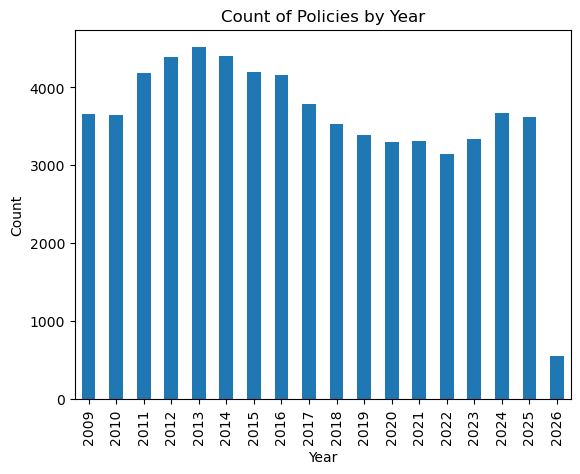

In [12]:
# Convert policyEffectiveDate to datetime and extract year
df_nfip_policies['policyEffectiveDate'] = pd.to_datetime(df_nfip_policies['policyEffectiveDate'], errors='coerce')
df_nfip_policies['policyEffectiveYear'] = df_nfip_policies['policyEffectiveDate'].dt.year

# plot count of policites by year
df_nfip_policies['policyEffectiveYear'].value_counts().sort_index().plot(kind='bar')
plt.xlabel('Year')
plt.ylabel('Count')
plt.title('Count of Policies by Year')
plt.show()